1. Consider the logistic map as defined in your earlier assignment, 𝑥𝑛+1 = 𝑟𝑥𝑛(1 − 𝑥𝑛).

Recall that 𝑟 is a parameter such that, 0 < 𝑟 < 4 and 𝑥0 ∈ (0, 1), note that 𝑥0 should not
start with 0 or 1.0. 

This function generates a sequence of values from a starting value 𝑥0.

This function is remarkable because it shows that even a simple function like this can
produce rapid period doubling and eventual chaotic output. Let us try to capture this in
the following manner. (10 marks)
    
    a. Consider 1000 values of 𝑟 between 1.0 and 4.0, uniformly spaced.
    b. For each value of 𝑟 start with a random value of 𝑥0 drawn from a uniform distribution
    (between 0 and 1).
    c. Iterate over the logistic map to generate 200 values of the sequence for each value of
    𝑟. Store only the last 100 values of the iteration, i.e. store 𝑥100 to 𝑥199.

    d. Now plot the 𝑟 vs 𝑥𝑖 using a small dot (i.e. the marker used to show the point should
    be small). That is, plot 𝑟 on the x-axis and the last 100 values of the sequence (𝑥100
    to 𝑥199) on the y-axis using small dots.

    e. In a separate figure, zoom the plot by setting the limits of the plot suitably and
    show the interesting region of the plot as a separate plot .

In [41]:
import numpy as np
import matplotlib.pyplot as plt


def logistic_map(x, r):
    return r * x * (1 - x)

r_values = np.linspace(1.0, 4.0, 1000)

rng = np.random.default_rng(42)
x0_values = rng.uniform(1e-12, 1 - 1e-12, size=r_values.size)

last_100_values = np.empty((r_values.size, 100))

for idx, (r, x) in enumerate(zip(r_values, x0_values)):
    trajectory = np.empty(200)
    for i in range(200):
        x = logistic_map(x, r)
        trajectory[i] = x
    last_100_values[idx] = trajectory[100:200]

print(f"r_values shape: {r_values.shape}")
print(f"x0_values shape: {x0_values.shape}")
print(f"stored x100 to x199 shape: {last_100_values.shape}")

r_values shape: (1000,)
x0_values shape: (1000,)
stored x100 to x199 shape: (1000, 100)


2. The famous Collatz sequence can be generated for any positive integer as follows:

    i. Start with an arbitrary (positive) integer.
    ii. If the number is even, divide by 2; if the number is odd, multiply by 3 and add 1.

    iii. Repeat the procedure with the new number.
    iv. It appears that for all starting values there is a cycle of 4, 2, 1 at which the procedure
    loops. You should stop when the value goes to 1. The resulting sequence of values
    is the Collatz sequence.

    1. Now, write a function called collatz that generates the sequence (as a list of
    integers) for any starting integer value. You may assume that this function is only
    given an integer. It should return a list of integers. (5 marks)

    2. Write a function plot_stopping that considers all values of integers from 1 to the
    passed integer n and plots the starting number on the x-axis and the length of the
    Collatz sequence for that particular number. Show the result for the first 1000
    numbers. (5 marks)

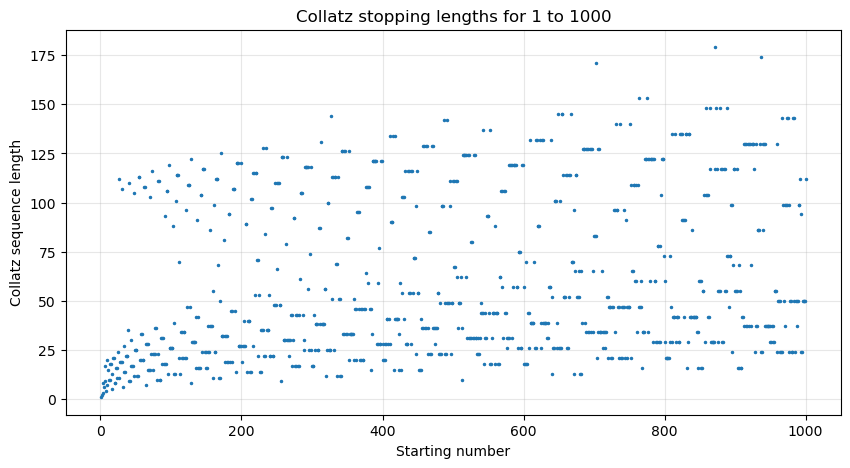

In [36]:
def collatz(start):
    if start <= 0:
        raise ValueError("start must be a positive integer")

    sequence = [int(start)]
    value = int(start)

    while value != 1:
        if value % 2 == 0:
            value = value // 2
        else:
            value = 3 * value + 1
        sequence.append(value)
    return sequence


def plot_stopping(n):
    if n < 1:
        raise ValueError("n must be at least 1")

    starts = list(range(1, n + 1))
    lengths = [len(collatz(x)) for x in starts]

    plt.figure(figsize=(10, 5))
    plt.plot(starts, lengths, '.', markersize=3)
    plt.xlabel('Starting number')
    plt.ylabel('Collatz sequence length')
    plt.title(f'Collatz stopping lengths for 1 to {n}')
    plt.grid(True, alpha=0.3)
    plt.show()

# Show result for first 1000 numbers
plot_stopping(1000)

3. Consider the 5 batsmen, 
Rohit, Gambhir, Kohli, Sachin, and Sehwag 
and their ODI scores
(which has already been shared with you). 

Compute their probability mass function as done in class using their scores. 

Then use this to find the probability that they will score

more than 50 if they have crossed 5 runs. 

Print this information for each batsman. 

Do this in a loop rather than 5 cut-pasted code-blocks. (5 marks)

In [47]:
import numpy as np


def compute_pmf(scores):
    max_score = int(np.max(scores))
    bins = np.arange(0, max_score + 2)
    pmf, edges = np.histogram(scores, bins=bins, density=True)
    support = edges[:-1]
    return support, pmf


def conditional_probability(support, pmf, event_threshold=50, condition_threshold=5):
    p_event_and_condition = pmf[support > event_threshold].sum()
    p_condition = pmf[support > condition_threshold].sum()
    return p_event_and_condition / p_condition if p_condition > 0 else 0.0


batsmen_files = {
    "Rohit": "rohit.txt",
    "Gambhir": "gambhir.txt",
    "Kohli": "kohli.txt",
    "Sachin": "sachin.txt",
    "Sehwag": "sehwag.txt",
}

for name, file_name in batsmen_files.items():
    scores = np.loadtxt(file_name)
    support, pmf = compute_pmf(scores)
    prob = conditional_probability(support, pmf, event_threshold=50, condition_threshold=5)
    print(f"{name}: Probability of scoring 50 when they have scored 5 runs. P(X > 50 | X > 5) = {prob:.4f}")


print('Kohli has the highest conditional probability of scoring 50 runs having observed that he has scored 5 runs')

Rohit: Probability of scoring 50 when they have scored 5 runs. P(X > 50 | X > 5) = 0.4306
Gambhir: Probability of scoring 50 when they have scored 5 runs. P(X > 50 | X > 5) = 0.3793
Kohli: Probability of scoring 50 when they have scored 5 runs. P(X > 50 | X > 5) = 0.5187
Sachin: Probability of scoring 50 when they have scored 5 runs. P(X > 50 | X > 5) = 0.3972
Sehwag: Probability of scoring 50 when they have scored 5 runs. P(X > 50 | X > 5) = 0.2746
Kohli has the highest conditional probability of scoring 50 runs having observed that he has scored 5 runs
